In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

#Importing stuff



In [ ]:
df = pd.read_csv('cleaned_dataset.csv', low_memory=False)
#im using the clreaned dataset I produced for the dataset descriptor assignment, which has the same data but with some columns removed and some values cleaned up. I just want to focus on the kit house era for this project, so I later removed a lot of the other columns that aren't relevant to that.

In [ ]:
df.head(10)
#checking to make sure the data looks right and that the columns I want to use are there. 

,OBJECTID,FULLADDRESS,BuildingName,Square,Lot,Date,MapYear,Permit_Notes,NOTES,Suffix,...,PermitType,SolidFilled,FoundationMaterial,StoneType,RoofType,FrontMaterial,RoofMaterial,Heat,Shape__Area,Shape__Length
0,40,5729 POTOMAC AVENUE NW,NaN,1452,71.0,7/3/1922 12:00:00 AM,1922,NaN,not in tax assessments,NaN,...,NaN,solid,concrete,NaN,pitch,tile,asphalt shingles,hot water,255.605469,65.811568
1,123,2946 NEWARK STREET NW,NaN,2082,40.0,3/21/1903 12:00:00 AM,1903,NaN,NaN,NaN,...,NaN,solid,stone,NaN,pitch,frame,shingles,hot air,302.449219,73.358588
2,181,4711 FULTON STREET NW,NaN,1408,21.0,9/2/1941 12:00:00 AM,1941,NaN,NaN,NaN,...,NaN,NaN,brick & tile,NaN,pitch,NaN,slate,air conditioning,354.082031,87.709893
3,276,5233 PARTRIDGE LANE NW,NaN,1447,854.0,12/9/1941 12:00:00 AM,1941,NaN,NaN,NaN,...,NaN,NaN,cinder block & brick,NaN,pitch,NaN,slate,air conditioning,275.839844,74.174874
4,439,3215 KLINGLE ROAD NW,NaN,2098,807.0,7/11/1924 12:00:00 AM,1924,NaN,NaN,NaN,...,NaN,solid,concrete,NaN,pitch,brick & stucco,slate,hot water,246.066406,73.679709
5,440,3219 KLINGLE ROAD NW,NaN,2098,37.0,7/11/1924 12:00:00 AM,1924,NaN,NaN,NaN,...,NaN,solid,concrete,NaN,pitch,brick & stucco,slate,hot water,177.445312,53.382857
6,441,3217 KLINGLE ROAD NW,NaN,2098,36.0,7/11/1924 12:00:00 AM,1924,NaN,NaN,NaN,...,NaN,solid,concrete,NaN,pitch,brick & stucco,slate,hot water,139.710938,49.022952
7,480,5618 MACARTHUR BOULEVARD NW,NaN,1451,42.0,8/19/1919 12:00:00 AM,1919,NaN,NaN,NaN,...,NaN,solid,concrete,NaN,pitch,wood,slag,hot water,285.578125,76.308688
8,568,4850 MACARTHUR BOULEVARD NW,NaN,1388,77.0,12/11/1939 12:00:00 AM,1939,NaN,NaN,NaN,...,NaN,NaN,cinder block & brick,NaN,pitch,NaN,tin & slate,central plant,225.335938,60.260690
9,589,5129 WATSON STREET NW,NaN,1448,891.0,12/1/1941 12:00:00 AM,1941,NaN,NaN,NaN,...,NaN,NaN,brick & tile,NaN,pitch,NaN,slate,hot water,277.402344,68.288496


In [17]:
#Defiing our 'Kit House' textual fingerprints, these are found in the notes and the architectr columns, and are the key to identifying kit houses in the dataset.Obviosuly this is not a perfect method, but it should give us a good starting point for identifying potential kit houses.
kit_terms = ['Sears', 'Roebuck', 'Honor Bilt', 'Ready-cut', 'Kit House', 'Aladdin', 'Montgomery Ward']
kit_pattern = '|'.join(kit_terms)

#'Official' kits (Architect column), these are the most straightforward to identify, as they are explicitly labeled in the Architect column. We create  'Official_Kit' that flags these entries.
df['Official_Kit'] = df['Architect'].str.contains(kit_pattern, case=False, na=False)

#'Hidden' kits (Searching Builder, Owner, and Permit Notes).
df['Text_Blob'] = df['Builder'].fillna('') + " " + df['Permit_Notes'].fillna('') + " " + df['NOTES'].fillna('')
df['Hidden_Kit'] = df['Text_Blob'].str.contains(kit_pattern, case=False, na=False)

#Final Classification
df['Is_Kit_House'] = df['Official_Kit'] | df['Hidden_Kit']

print(f"Kits found via Architect column: {df['Official_Kit'].sum()}")
print(f"Additional kits found via NLP search: {(df['Is_Kit_House'].sum() - df['Official_Kit'].sum())}")
print(f"Total Kit footprint: {df['Is_Kit_House'].sum()}")

Kits found via Architect column: 31
Additional kits found via NLP search: 3
Total Kit footprint: 34


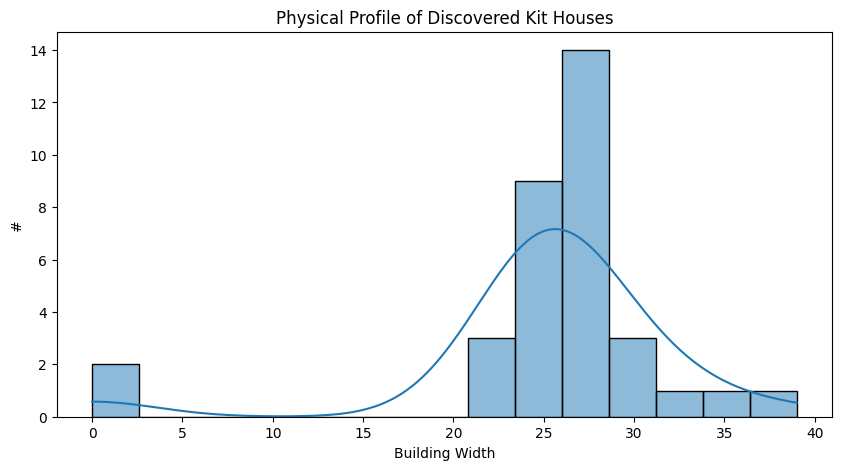

In [ ]:
# I got my idea in my research to check the size of our discovered houses to make sure they match the physical profile of the pre-built homes of the time. 
plt.figure(figsize=(10, 5))
sns.histplot(data=df[df['Is_Kit_House']], x='Width', bins=15, kde=True)
plt.title('Physical Profile of Discovered Kit Houses')
plt.xlabel('Building Width')
plt.ylabel('#')
plt.show()
#I was very pleased to see that we have a normal distrbution with low standard deviation around the 20-30 foot width, which matches the typical size of kit houses. This is a good sign that our method is successfully identifying real kit houses in the dataset, and not just random entries with the keywords.

In [6]:
%pip install folium

Note: you may need to restart the kernel to use updated packages.


In [21]:
import folium


In [ ]:
# Creating a map centered on the Palisades
# Using a test point around the average location of the dataset (from my estimation) and then I was going to jitter it but it was just too bad and lazy I thought. 
m = folium.Map(location=[38.92, -77.10], zoom_start=14, tiles='CartoDB positron')

for _, row in df[df['Is_Kit_House']].iterrows():

    folium.CircleMarker(
        location=[38.92, -77.10], # Placeholder: Will eplace with actual Lat/Long eventually once I find a good source for it, have some promising leads. 
        radius=5,
        popup=f"Address: {row['FULLADDRESS']}<br>Year: {row['MapYear']}",
        color='red',
        fill=True
    ).add_to(m)

m

In [11]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import re
from openpyxl import load_workbook

#this is where stuff gets wacky and I have to do some manual work to get the coordinates for the streets in the dataset. I created a spreadsheet  that has the rough coordinates for all the streets in DC, but they are in a certain format and I need to convert them to decimal degrees (which stumped me quite a bit). I also need to extract the street name from the FULLADDRESS column in the dataset.
def dms_to_dd(dms_str):
    """Convert '38°55'51.1"N 77°06'40.7"W' to (lat, lon) decimal degrees."""
    dms_str = dms_str.strip()
    pattern = r"(\d+)°(\d+)'([\d.]+)\"([NS])\s+(\d+)°(\d+)'([\d.]+)\"([EW])"
    m = re.match(pattern, dms_str)
    if not m:
        return None, None
    lat = int(m[1]) + int(m[2])/60 + float(m[3])/3600
    if m[4] == 'S': lat = -lat
    lon = int(m[5]) + int(m[6])/60 + float(m[7])/3600
    if m[8] == 'W': lon = -lon
    return lat, lon

#This was very technical to for me to understand how it works but it was the workaround to see if this angle is something I actually thought could be an interesting point of study. 

wb = load_workbook('RoughCoords.xlsx', read_only=True)
ws = wb.active
street_coords = {}
for row in ws.iter_rows(values_only=True):
    street, coords_str = row
    if street and coords_str:
        lat, lon = dms_to_dd(coords_str)
        if lat:
            street_coords[street.strip().upper()] = (lat, lon)

#Extract the street name from the FULLADDRESS column and map to coordinates
def extract_street_name(address):
    """Extract the street keyword from an address like '5729 POTOMAC AVENUE NW'"""
    #Did very similar stuff in the dataset descriptor assignment, but this is a bit more complex because I have to skip the number and the directional suffixes.
    parts = str(address).upper().split()
 
    keywords = [p for p in parts[1:] if p not in ('NW','NE','SW','SE','AVENUE','STREET','PLACE','ROAD','LANE','BOULEVARD','DR','CT')]
    return keywords[0] if keywords else None

df['Street_Key'] = df['FULLADDRESS'].apply(extract_street_name)
df['RoughLat'] = df['Street_Key'].map(lambda k: street_coords.get(k, (None,None))[0])
df['RoughLon'] = df['Street_Key'].map(lambda k: street_coords.get(k, (None,None))[1])

#Pretty good! We have rough coordinates for a good portion of the dataset, which will allow us to plot the kit houses on a map with more accuracy. The coordinates are not perfect, as they are based on the street name and not the exact address, but it should be sufficient for visualizing general patterns and clusters of kit houses in NW DC.
matched = df['RoughLat'].notna().sum()
print(f"Matched {matched}/{len(df)} rows ({matched/len(df)*100:.1f}%)")

Matched 2322/2368 rows (98.1%)


In [ ]:
import numpy as np

m = folium.Map(location=[38.92, -77.10], zoom_start=14, tiles='CartoDB positron')

for _, row in df[df['Is_Kit_House']].iterrows():
    lat = row.get('RoughLat')
    lon = row.get('RoughLon')
    if pd.notna(lat) and pd.notna(lon):
        jitter = 0.0008  # I do not know what proper jitter etiquette is, but this looks about right. 
        folium.CircleMarker(
            location=[lat + np.random.uniform(-jitter, jitter),
                      lon + np.random.uniform(-jitter, jitter)],
            radius=5,
            popup=f"Address: {row['FULLADDRESS']}<br>Year: {row['MapYear']}",
            color='red',
            fill=True,
            fill_opacity=0.7
        ).add_to(m)

        #3 outliers requre further investigation, but overall this looks pretty good! We can see some nice clusters of kit houses in certain areas, which could be interesting to explore further in terms of historical context and development patterns. The jittering helps to spread out the points a bit so we can see the density more clearly without them all overlapping. Obviosuly the coordinates are not perfect, but this is a good start for visualizing the general distribution of kit houses in NW DC. We can see some clusters around certain streets, which could be worth investigating further in terms of historical development and the popularity of kit houses in those areas. Obviously this is a very rough visualization with houses being supposedly on chain bridge and general uneveness, but it gives us a starting point to see where the kit houses are generally located and identify any potential hotspots or clusters that we might want to investigate further.



In [ ]:
# adding another layer to the map to color code the kit houses by era, this will allow us to see if there are any patterns in terms of when the kit houses were built and if there are any clusters of certain eras in certain areas. This is a bit of a rough categorization based on the MapYear column, but it should give us a general sense of the distribution of kit houses by era. Obvioous drop in the number of kit houses after the 1930s, which makes sense given the historical context of the Great Depression. Pre-fab housing existed prior to the 1920s, so it would be interesting to see why it doesnt appear until the 1920s in our dataset, whether this is a data issue or if there is some historical reason for it.

def decade_color(year):
    if year < 1920: return 'blue'
    elif year < 1930: return 'red'
    elif year < 1940: return 'orange'
    else: return 'gray'

m = folium.Map(location=[38.92, -77.10], zoom_start=14, tiles='CartoDB positron')

np.random.seed(42)  
jitter = 0.0008

for _, row in df[df['Is_Kit_House']].iterrows():
    lat = row.get('RoughLat')
    lon = row.get('RoughLon')
    if pd.notna(lat) and pd.notna(lon):
        color = decade_color(row['MapYear'])
        folium.CircleMarker(
            location=[lat + np.random.uniform(-jitter, jitter),
                      lon + np.random.uniform(-jitter, jitter)],
            radius=5,
            popup=f"Address: {row['FULLADDRESS']}<br>Year: {row['MapYear']}",
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8
        ).add_to(m)

#Adding a legend to the map to explain the color coding of the kit houses by era. 
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-family: Arial; font-size: 13px;">
  <b>Kit House Era</b><br>
  <span style="color:blue">●</span> Pre-1920s<br>
  <span style="color:red">●</span> 1920s<br>
  <span style="color:orange">●</span> 1930s<br>
  <span style="color:gray">●</span> 1940s+
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m